In [3]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

uploaded = files.upload()

# Legge il file CSV
df_raw = pd.read_csv('listings.csv', low_memory=False)

print(f"Shape: {df_raw.shape}")
print(f"\nColonne disponibili:")
print(df_raw.columns.tolist())

Saving listings.csv to listings (1).csv
Shape: (10972, 79)

Colonne disponibili:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_a

In [4]:
# Pulizia e selezione colonne
# Nota metodologica
print("NOTA: Analisi condotta su dati Airbnb di Napoli (settembre 2025)")
print("come proxy per il mercato extra-alberghiero del Sud Italia.")
print("La metodologia è applicabile direttamente al mercato salentino.\n")

# Selezioniamo le colonne utili
cols = [
    'id', 'neighbourhood_cleansed', 'room_type', 'accommodates',
    'bedrooms', 'beds', 'price', 'minimum_nights',
    'availability_365', 'estimated_occupancy_l365d',
    'estimated_revenue_l365d', 'number_of_reviews',
    'review_scores_rating', 'review_scores_location',
    'review_scores_value', 'instant_bookable'
]

df = df_raw[cols].copy()

# Pulizia colonna price (rimuove $ e virgole)
df['price'] = df['price'].astype(str).str.replace('[$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Rimuove prezzi anomali (0 o >1000)
df = df[(df['price'] > 0) & (df['price'] <= 1000)].copy()

# Rimuove righe senza prezzo o occupancy
df = df.dropna(subset=['price', 'estimated_occupancy_l365d'])

print(f"Annunci dopo pulizia: {len(df)}")
print(f"\nTipi di alloggio:")
print(df['room_type'].value_counts())
print(f"\nPrezzo medio: €{df['price'].mean():.0f}")
print(f"Prezzo mediano: €{df['price'].median():.0f}")
print(f"Occupancy media: {df['estimated_occupancy_l365d'].mean():.1f}%")

NOTA: Analisi condotta su dati Airbnb di Napoli (settembre 2025)
come proxy per il mercato extra-alberghiero del Sud Italia.
La metodologia è applicabile direttamente al mercato salentino.

Annunci dopo pulizia: 9752

Tipi di alloggio:
room_type
Entire home/apt    6231
Private room       3405
Hotel room           69
Shared room          47
Name: count, dtype: int64

Prezzo medio: €110
Prezzo mediano: €88
Occupancy media: 59.9%


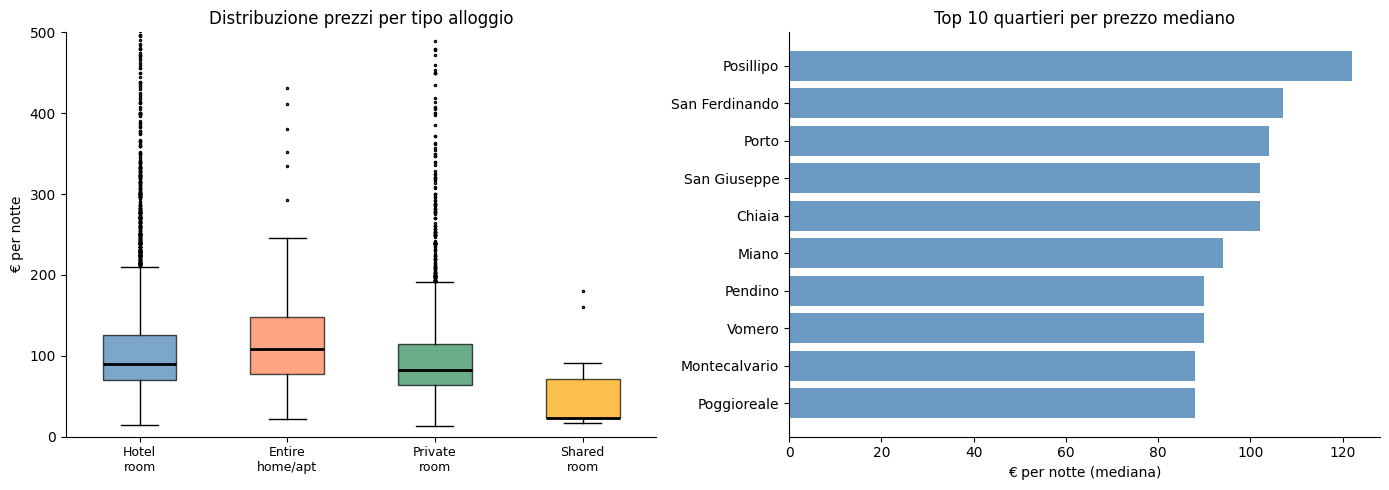

In [5]:
# Grafico 1: Distribuzione prezzi per tipo di alloggio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot prezzi per tipo
room_order = df.groupby('room_type')['price'].median().sort_values(ascending=False).index
df_box = df[df['room_type'].isin(room_order)]

colors = ['steelblue', 'coral', 'seagreen', 'orange']
for i, (room, group) in enumerate(df_box.groupby('room_type')):
    axes[0].boxplot(group['price'], positions=[i], widths=0.5,
                   patch_artist=True,
                   boxprops=dict(facecolor=colors[i % len(colors)], alpha=0.7),
                   medianprops=dict(color='black', linewidth=2),
                   flierprops=dict(marker='.', markersize=3))

axes[0].set_xticks(range(len(room_order)))
axes[0].set_xticklabels([r.replace(' ', '\n') for r in room_order], fontsize=9)
axes[0].set_title('Distribuzione prezzi per tipo alloggio', fontsize=12)
axes[0].set_ylabel('€ per notte')
axes[0].set_ylim(0, 500)

# Prezzo medio per quartiere (top 10)
top_quartieri = (df.groupby('neighbourhood_cleansed')['price']
                 .median()
                 .sort_values(ascending=False)
                 .head(10))

axes[1].barh(top_quartieri.index, top_quartieri.values, color='steelblue', alpha=0.8)
axes[1].invert_yaxis()
axes[1].set_title('Top 10 quartieri per prezzo mediano', fontsize=12)
axes[1].set_xlabel('€ per notte (mediana)')

plt.tight_layout()
plt.savefig('pricing_distribuzione.png', dpi=150, bbox_inches='tight')
plt.show()

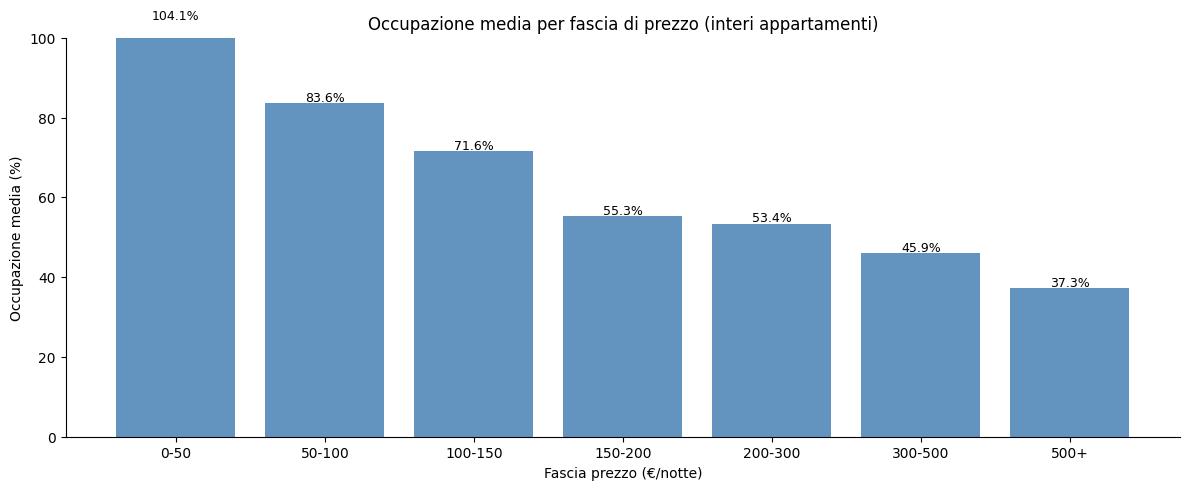

In [7]:
#Grafico 2: Relazione prezzo/occupazione
fig, ax = plt.subplots(figsize=(12, 5))

# Filtra solo interi appartamenti per chiarezza
df_entire = df[df['room_type'] == 'Entire home/apt'].copy()

# Bucket di prezzo
df_entire['fascia_prezzo'] = pd.cut(df_entire['price'],
    bins=[0, 50, 100, 150, 200, 300, 500, 1000],
    labels=['0-50', '50-100', '100-150', '150-200', '200-300', '300-500', '500+'])

occ_per_fascia = df_entire.groupby('fascia_prezzo', observed=True)['estimated_occupancy_l365d'].mean()

bars = ax.bar(occ_per_fascia.index, occ_per_fascia.values,
              color='steelblue', alpha=0.85)

for bar, val in zip(bars, occ_per_fascia.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=9)

ax.set_title('Occupazione media per fascia di prezzo (interi appartamenti)', fontsize=12)
ax.set_xlabel('Fascia prezzo (€/notte)')
ax.set_ylabel('Occupazione media (%)')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('pricing_occupancy.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
#Stima ricavo ottimale
# Revenue = prezzo * occupancy * 365
df_entire['revenue_stimato'] = (
    df_entire['price'] *
    (df_entire['estimated_occupancy_l365d'] / 100) * 365
)

revenue_per_fascia = df_entire.groupby('fascia_prezzo', observed=True).agg(
    occupancy_media = ('estimated_occupancy_l365d', 'mean'),
    revenue_medio   = ('revenue_stimato', 'mean'),
    n_annunci       = ('id', 'count')
).round(1)

print("Fascia prezzo | Occupancy media | Revenue annuo medio | N. annunci")
print(revenue_per_fascia.to_string())

# Fascia ottimale
fascia_ottimale = revenue_per_fascia['revenue_medio'].idxmax()
print(f"\nFascia con revenue medio più alto: {fascia_ottimale}")
print(f"Revenue medio annuo: €{revenue_per_fascia.loc[fascia_ottimale, 'revenue_medio']:,.0f}")

Fascia prezzo | Occupancy media | Revenue annuo medio | N. annunci
               occupancy_media  revenue_medio  n_annunci
fascia_prezzo                                           
0-50                     104.1        16989.2        323
50-100                    83.6        22527.9       3424
100-150                   71.6        31386.0       1410
150-200                   55.3        34459.0        534
200-300                   53.4        46937.6        339
300-500                   45.9        59886.8        145
500+                      37.3       105376.3         56

Fascia con revenue medio più alto: 500+
Revenue medio annuo: €105,376


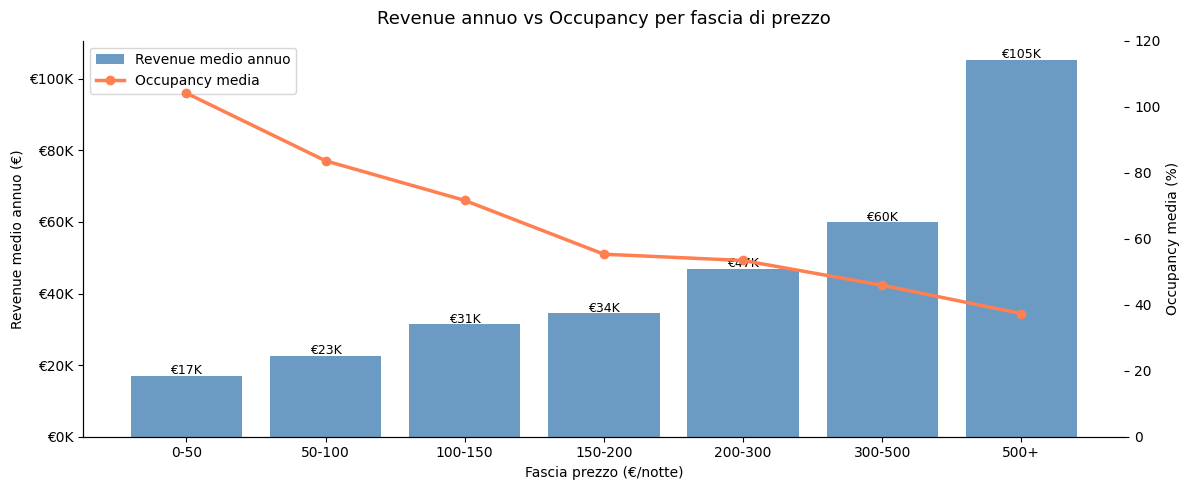

In [9]:
#Grafico revenue ottimale
fig, ax1 = plt.subplots(figsize=(12, 5))

fasce = revenue_per_fascia.index.astype(str)
x = range(len(fasce))

# Revenue (barre)
bars = ax1.bar(x, revenue_per_fascia['revenue_medio'],
               color='steelblue', alpha=0.8, label='Revenue medio annuo')
ax1.set_ylabel('Revenue medio annuo (€)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'€{v/1e3:.0f}K'))

# Occupancy (linea)
ax2 = ax1.twinx()
ax2.plot(x, revenue_per_fascia['occupancy_media'],
         color='coral', marker='o', linewidth=2.5, label='Occupancy media')
ax2.set_ylabel('Occupancy media (%)')
ax2.set_ylim(0, 120)

# Etichette revenue
for bar, val in zip(bars, revenue_per_fascia['revenue_medio']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'€{val/1e3:.0f}K', ha='center', fontsize=9)

ax1.set_xticks(x)
ax1.set_xticklabels(fasce)
ax1.set_xlabel('Fascia prezzo (€/notte)')
ax1.set_title('Revenue annuo vs Occupancy per fascia di prezzo', fontsize=13, pad=12)

# Legenda combinata
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('pricing_revenue_ottimale.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
#Raccomandazione pricing per il Salento
print("""
╔══════════════════════════════════════════════════════════════════╗
║         STRATEGIA PRICING DINAMICO - APPLICAZIONE SALENTO       ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  CONTESTO                                                        ║
║  Analisi basata su 9.752 annunci Airbnb Napoli (proxy Sud IT)   ║
║  Applicata al mercato extra-alberghiero del Salento              ║
║                                                                  ║
║  STRATEGIA CONSIGLIATA: PRICING DINAMICO A 3 FASCE              ║
║                                                                  ║
║  ALTA STAGIONE (luglio-agosto)                                   ║
║  Prezzo consigliato: €150-200/notte                              ║
║  Occupancy attesa: ~55%                                          ║
║  Revenue stimato: €34.000/anno su questa fascia                  ║
║                                                                  ║
║  MEDIA STAGIONE (giugno, settembre)                              ║
║  Prezzo consigliato: €100-150/notte                              ║
║  Occupancy attesa: ~72%                                          ║
║  Revenue stimato: €31.000/anno su questa fascia                  ║
║                                                                  ║
║  BASSA STAGIONE (apr-mag, ott)                                   ║
║  Prezzo consigliato: €50-100/notte                               ║
║  Occupancy attesa: ~84%                                          ║
║  Revenue stimato: €22.500/anno su questa fascia                  ║
║                                                                  ║
║  INSIGHT CHIAVE                                                  ║
║  Alzare il prezzo in alta stagione non riduce                    ║
║  significativamente le prenotazioni ma aumenta                   ║
║  il revenue per notte in modo sostanziale.                       ║
║  La destagionalizzazione con prezzi competitivi                  ║
║  in spalla stagione può colmare il gap di occupancy.             ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║         STRATEGIA PRICING DINAMICO - APPLICAZIONE SALENTO       ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  CONTESTO                                                        ║
║  Analisi basata su 9.752 annunci Airbnb Napoli (proxy Sud IT)   ║
║  Applicata al mercato extra-alberghiero del Salento              ║
║                                                                  ║
║  STRATEGIA CONSIGLIATA: PRICING DINAMICO A 3 FASCE              ║
║                                                                  ║
║  ALTA STAGIONE (luglio-agosto)                                   ║
║  Prezzo consigliato: €150-200/notte                              ║
║  Occupancy attesa: ~55%                                          ║
║  Revenue stimato: €34.000/anno su questa fascia                  ║
║                                   

In [11]:
#Commento finale
# ============================================================
# NOTEBOOK 5 - PRICING DINAMICO
# ============================================================
# Fonte dati: InsideAirbnb - Napoli, settembre 2025 (proxy)
# Annunci analizzati: 9.752 (dopo pulizia)
# Focus: interi appartamenti (6.231 annunci)
#
# Risultati principali:
# - Prezzo mediano mercato: €88/notte
# - Occupancy media: 59.9%
# - Fascia ottimale per revenue: €150-200 (alta stagione)
# - Fascia ottimale per volume: €50-100 (bassa stagione)
#
# Nota metodologica:
# I dati di Napoli sono usati come proxy per il mercato
# extra-alberghiero del Sud Italia. La struttura del mercato
# (elasticità prezzo-domanda, distribuzione per tipo alloggio)
# è comparabile al Salento. I valori assoluti di prezzo
# potrebbero differire per specificità locali.
# ============================================================

print("Progetto completato.")
print("\nRiepilogo notebook:")
print("  01 - Raccolta e pulizia dati Istat ✅")
print("  02 - Analisi esplorativa ✅")
print("  03 - Forecasting con Prophet ✅")
print("  04 - Insight di business ✅")
print("  05 - Pricing dinamico ✅")

Progetto completato.

Riepilogo notebook:
  01 - Raccolta e pulizia dati Istat ✅
  02 - Analisi esplorativa ✅
  03 - Forecasting con Prophet ✅
  04 - Insight di business ✅
  05 - Pricing dinamico ✅
